In [26]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn  as sns
from scipy import stats
import hashlib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_score, recall_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import mlflow
import mlflow.sklearn


from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score
)

In [27]:
with open('dados_etapa1.pkl', 'rb') as f:
    dados = pickle.load(f)

X_train_scaled = dados['X_train_scaled']
X_test_scaled  = dados['X_test_scaled']
X_val_scaled   = dados['X_val_scaled']
X_train        = dados['X_train']
X_test         = dados['X_test']
y_train        = dados['y_train']
y_test         = dados['y_test']
y_val          = dados['y_val']
dataset_meta   = dados['dataset_meta']
metricas_dummy = dados['metricas_dummy']
metricas_lr    = dados['metricas_lr']
y_pred_dummy   = dados['y_pred_dummy']
y_pred_lr      = dados['y_pred_lr']

def calcular_metricas(y_true, y_pred, y_proba):
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'f1_score':  f1_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall':    recall_score(y_true, y_pred),
        'roc_auc':   roc_auc_score(y_true, y_proba),
        'pr_auc':    average_precision_score(y_true, y_proba),
    }

print('Dados da Etapa 1 carregados')

Dados da Etapa 1 carregados


## Etapa 2

In [28]:
import torch
import torch.nn as nn

In [29]:
X_train_np = np.array(X_train_scaled).astype(float)
X_train_tensor = torch.tensor(X_train_np, dtype=torch.float)

X_test_np = np.array(X_test_scaled).astype(float)
X_test_tensor = torch.tensor(X_test_np, dtype=torch.float)

X_val_np     = np.array(X_val_scaled).astype(float)
X_val_tensor = torch.tensor(X_val_np, dtype=torch.float)

In [30]:
y_train_np = np.array(y_train).astype(float)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float)

y_test_np = np.array(y_test).astype(float)
y_test_tensor = torch.tensor(y_test_np, dtype=torch.float)

y_val_np     = np.array(y_val).astype(float)
y_val_tensor = torch.tensor(y_val_np, dtype=torch.float)

In [31]:
print(type(X_train_tensor))
print(type(X_test_tensor))

<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [32]:
print((X_train_tensor).shape)
print((y_train_tensor).shape)

torch.Size([5282, 29])
torch.Size([5282])


In [33]:
#Pra ficar igual o formato do X_train_tensor, que tem 2 dimensões, e o y_train_tensor, que tem 1 dimensão, a gente precisa adicionar uma dimensão extra no y_train_tensor usando unsqueeze(1)
y_train_tensor = y_train_tensor.unsqueeze(1)

In [34]:
dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)

In [35]:
type(dataset)

torch.utils.data.dataset.TensorDataset

In [36]:
train_loader = torch.utils.data.DataLoader(dataset, batch_size=10, shuffle=True)

## Construção do Modelo

In [37]:
val_dataset = torch.utils.data.TensorDataset(X_val_tensor, y_val_tensor.unsqueeze(1))
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=10)
EPOCHS    = 10000
PATIENCE  = 10
LR        = 0.001

#Quantos neuronios na entrada
input_dim  = X_train_scaled.shape[1]
hidden_dim = input_dim // 2 # qtd de neuronios na camada oculta

In [38]:
print(input_dim)
print(hidden_dim)

29
14


In [39]:
mlflow.end_run()
mlflow.set_experiment("Telco-Churn")

with mlflow.start_run(run_name="mlp_pytorch"):
    mlflow.log_params(dataset_meta)
    mlflow.log_params({
        "arquitetura":   f"{input_dim}-{hidden_dim}-{hidden_dim}-1",
        "ativacao":      "ReLU",
        "loss_function": "BCELoss",
        "optimizer":     "Adam",
        "learning_rate": LR,
        "batch_size":    10,
        "patience":      PATIENCE,
        "max_epochs":    EPOCHS,
    })

    classificador = nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, 1),
        nn.Sigmoid()
    )

    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(classificador.parameters(), lr=LR, weight_decay=0.0001)

    best_val_loss = float('inf')
    counter       = 0
    epoca_parada  = 0

    for epoch in range(EPOCHS):
        # Treino
        classificador.train()
        train_loss = 0.0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs    = classificador(inputs)
            loss       = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # Validação
        classificador.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs   = classificador(inputs)
                loss      = criterion(outputs, labels)
                val_loss += loss.item()
        val_loss /= len(val_loader)

        mlflow.log_metric("train_loss", train_loss, step=epoch)
        mlflow.log_metric("val_loss",   val_loss,   step=epoch)
        print(f"Época {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter       = 0
            epoca_parada  = epoch + 1
            torch.save(classificador.state_dict(), "best_mlp.pt")
        else:
            counter += 1

        if counter >= PATIENCE:
            print(f"Early stopping ativado na época {epoch+1}")
            break

    mlflow.log_param("epoca_parada",   epoca_parada)
    mlflow.log_metric("best_val_loss", best_val_loss)

    # Avaliação final
    classificador.load_state_dict(torch.load("best_mlp.pt"))
    classificador.eval()

    with torch.no_grad():
        proba_mlp = classificador(X_test_tensor).numpy().flatten()

    for t in [0.3, 0.4, 0.5]:
        pred_t = (proba_mlp >= t).astype(int)
        print(f"\n--- Threshold {t} ---")
        print(f"  F1:        {f1_score(y_test, pred_t):.4f}")
        print(f"  Precision: {precision_score(y_test, pred_t):.4f}")
        print(f"  Recall:    {recall_score(y_test, pred_t):.4f}")

    THRESHOLD = 0.4
    pred_mlp  = (proba_mlp >= THRESHOLD).astype(int)

    metricas_mlp = calcular_metricas(y_test, pred_mlp, proba_mlp)
    mlflow.log_metrics(metricas_mlp)
    mlflow.log_artifact("best_mlp.pt")

    print("\n=== MLP PYTORCH ===")
    for nome, valor in metricas_mlp.items():
        print(f"  {nome:<16}: {valor:.4f}")
    print(f"\n  Melhor Val Loss: {best_val_loss:.4f} (época {epoca_parada})")

    

Época 1 | Train Loss: 0.4628 | Val Loss: 0.4465
Época 2 | Train Loss: 0.4078 | Val Loss: 0.4357
Época 3 | Train Loss: 0.4007 | Val Loss: 0.4319
Época 4 | Train Loss: 0.3992 | Val Loss: 0.4312
Época 5 | Train Loss: 0.3946 | Val Loss: 0.4297
Época 6 | Train Loss: 0.3928 | Val Loss: 0.4282
Época 7 | Train Loss: 0.3909 | Val Loss: 0.4297
Época 8 | Train Loss: 0.3900 | Val Loss: 0.4268
Época 9 | Train Loss: 0.3885 | Val Loss: 0.4272
Época 10 | Train Loss: 0.3882 | Val Loss: 0.4260
Época 11 | Train Loss: 0.3850 | Val Loss: 0.4302
Época 12 | Train Loss: 0.3856 | Val Loss: 0.4307
Época 13 | Train Loss: 0.3837 | Val Loss: 0.4306
Época 14 | Train Loss: 0.3837 | Val Loss: 0.4257
Época 15 | Train Loss: 0.3831 | Val Loss: 0.4268
Época 16 | Train Loss: 0.3814 | Val Loss: 0.4256
Época 17 | Train Loss: 0.3821 | Val Loss: 0.4248
Época 18 | Train Loss: 0.3800 | Val Loss: 0.4239
Época 19 | Train Loss: 0.3789 | Val Loss: 0.4291
Época 20 | Train Loss: 0.3777 | Val Loss: 0.4260
Época 21 | Train Loss: 0.3773

<Axes: >

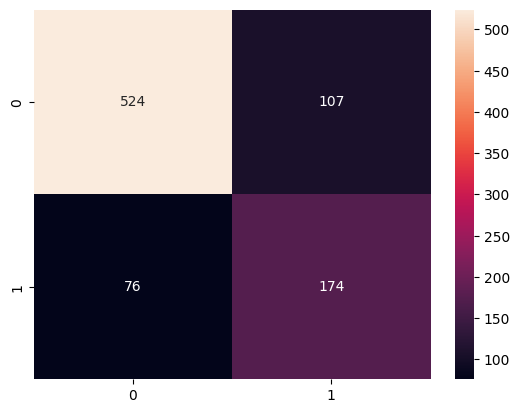

In [40]:
matriz_mlp = confusion_matrix(y_test, pred_mlp)

sns.heatmap(matriz_mlp, annot=True, fmt="d" )

### GridSearch
Para saber qual é a melhor profundidade para as árvores de decisão e random forest

In [41]:

#Para saber qual é a melhor profundidade para as árvores de decisão e random forest
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,                # validação cruzada com 5 folds
    scoring='roc_auc',   # métrica que você quer otimizar
    n_jobs=1
)

grid_search.fit(X_train, y_train)

print(f"Melhor max_depth: {grid_search.best_params_}")
print(f"Melhor ROC-AUC:   {grid_search.best_score_:.4f}")

# GridSearch para Random Forest
grid_forest = GridSearchCV(
    RandomForestClassifier(n_estimators=40, random_state=42),
    param_grid,
    cv=5, scoring='roc_auc', n_jobs=1
)
grid_forest.fit(X_train, y_train)
print(f"Melhor RF: {grid_forest.best_params_}")

Melhor max_depth: {'max_depth': 5}
Melhor ROC-AUC:   0.8307
Melhor RF: {'max_depth': 7}


### Decision Tree

In [42]:
from sklearn.tree import DecisionTreeClassifier

mlflow.end_run()

with mlflow.start_run(run_name="decision_tree_baseline"):
    mlflow.log_params(dataset_meta)

    tree = DecisionTreeClassifier(max_depth=7, random_state=42)
    tree.fit(X_train, y_train)

    y_pred_train_tree = tree.predict(X_train)
    y_pred_test_tree = tree.predict(X_test)
    y_proba_test_tree = tree.predict_proba(X_test)[:, 1]

    metricas_tree = calcular_metricas(y_test, y_pred_test_tree, y_proba_test_tree)
    metricas_tree["train_accuracy"] = accuracy_score(y_train, y_pred_train_tree)
    metricas_tree["overfitting"]    = metricas_tree["train_accuracy"] - metricas_tree["accuracy"]

    mlflow.log_metrics(metricas_tree)
    mlflow.sklearn.log_model(tree, "model")

    print("\n=== DECISION TREE ===")
    for nome, valor in metricas_tree.items():
        print(f"  {nome:<16}: {valor:.4f}")

2026/04/28 23:13:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 23:13:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== DECISION TREE ===
  accuracy        : 0.7991
  f1_score        : 0.6040
  precision       : 0.6853
  recall          : 0.5400
  roc_auc         : 0.8264
  pr_auc          : 0.6426
  train_accuracy  : 0.8262
  overfitting     : 0.0271


<Axes: >

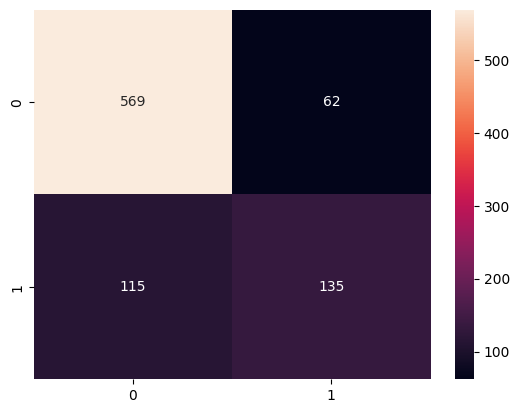

In [43]:
matriz_decision_tree = confusion_matrix(y_test, y_pred_test_tree)
sns.heatmap(matriz_decision_tree, annot=True,fmt="d")

### Random Forest

In [44]:
from sklearn.ensemble import RandomForestClassifier

mlflow.end_run()

with mlflow.start_run(run_name="random_forest_baseline"):
    mlflow.log_params(dataset_meta)

    forest = RandomForestClassifier(n_estimators=40, max_depth=15, criterion='entropy', random_state=42)
    forest.fit(X_train, y_train)

    y_pred_train_forest = forest.predict(X_train)
    y_pred_test_forest = forest.predict(X_test)
    y_proba_test_forest = forest.predict_proba(X_test)[:, 1]

    metricas_forest = calcular_metricas(y_test, y_pred_test_forest, y_proba_test_forest)
    metricas_forest["train_accuracy"] = accuracy_score(y_train, y_pred_train_forest)
    metricas_forest["overfitting"]    = metricas_forest["train_accuracy"] - metricas_forest["accuracy"]

    mlflow.log_metrics(metricas_forest)
    mlflow.sklearn.log_model(forest, "model")

    print("\n=== RANDOM FOREST ===")
    for nome, valor in metricas_forest.items():
        print(f"  {nome:<16}: {valor:.4f}")

2026/04/28 23:13:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 23:13:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== RANDOM FOREST ===
  accuracy        : 0.8138
  f1_score        : 0.6388
  precision       : 0.7108
  recall          : 0.5800
  roc_auc         : 0.8438
  pr_auc          : 0.6770
  train_accuracy  : 0.9756
  overfitting     : 0.1617


<Axes: >

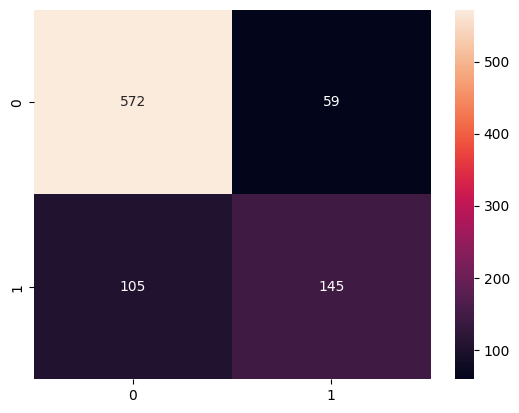

In [45]:
matriz_random_forest = confusion_matrix(y_test, y_pred_test_forest)
sns.heatmap(matriz_random_forest, annot=True, fmt="d")


## Tabela de comparação

In [46]:

df_runs = mlflow.search_runs(experiment_names=["Telco-Churn"])

colunas = [
    "tags.mlflow.runName",
    "start_time",
    "metrics.accuracy",
    "metrics.f1_score",
    "metrics.precision",
    "metrics.recall",
    "metrics.roc_auc",
    "metrics.pr_auc",
]

df_comparacao = df_runs[colunas].copy()
df_comparacao.columns = ["model", "start_time", "accuracy", "f1_score", "precision", "recall", "roc_auc", "pr_auc"]

df_comparacao = df_comparacao.dropna(subset=["roc_auc"])

df_comparacao = (
    df_comparacao
    .sort_values("start_time", ascending=False)
    .drop_duplicates(subset=["model"], keep="first")
    .drop(columns=["start_time"])
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)

# ── Impressão visual ──────────────────────────────────────────────────────────
metricas = ["accuracy", "f1_score", "precision", "recall", "roc_auc", "pr_auc"]
melhores = {col: df_comparacao[col].max() for col in metricas}

COL_MODELO = 28
COL_MET    = 11
BARRA      = "═" * (COL_MODELO + COL_MET * len(metricas) + 1)
cabecalhos = ["accuracy", "f1", "precision", "recall", "roc_auc", "pr_auc"]

print(f"\n{'COMPARAÇÃO DE MODELOS — Telco Churn':^{len(BARRA)}}")
print(BARRA)
print(f"{'model':<{COL_MODELO}}" + "".join(f"{h:>{COL_MET}}" for h in cabecalhos))
print("─" * len(BARRA))

for _, row in df_comparacao.iterrows():
    linha = f"{row['model']:<{COL_MODELO}}"
    for col in metricas:
        val = row[col]
        cel = f"{val:.4f}"
        # marca o melhor valor de cada coluna com ★
        if val == melhores[col]:
            cel = f"{cel}★"
        linha += f"{cel:>{COL_MET}}"
    print(linha)

print(BARRA)
print(f"  ★ melhor valor por coluna")
print()

# ranking final por roc_auc
melhor = df_comparacao.iloc[0]
print(f"  🏆 Melhor modelo  : {melhor['model']}")
print(f"     ROC-AUC        : {melhor['roc_auc']:.4f}")
print(f"     F1             : {melhor['f1_score']:.4f}")
print(f"     Recall         : {melhor['recall']:.4f}")



                              COMPARAÇÃO DE MODELOS — Telco Churn                              
═══════════════════════════════════════════════════════════════════════════════════════════════
model                          accuracy         f1  precision     recall    roc_auc     pr_auc
───────────────────────────────────────────────────────────────────────────────────────────────
logistic_regression_baseline    0.8138★     0.6511     0.6955     0.6120    0.8601★    0.7193★
mlp_pytorch                      0.7923     0.6554     0.6192     0.6960     0.8578     0.7110
clean-crane-350                  0.7900    0.6593★     0.6109    0.7160★     0.8566     0.7015
random_forest_baseline          0.8138★     0.6388    0.7108★     0.5800     0.8438     0.6770
decision_tree_baseline           0.7991     0.6040     0.6853     0.5400     0.8264     0.6426
dummy_baseline                   0.7162     0.0000     0.0000     0.0000     0.5000     0.2838
══════════════════════════════════════════════

## Trade Off


Modelo                       FP    FN     Custo FP     Custo FN     Resultado
---------------------------------------------------------------------------
Dummy                         0   250  R$        0  R$  125,000  R$  -125,000
Regressão Logística          67    97  R$    3,350  R$   48,500  R$   -36,550
Decision Tree                62   115  R$    3,100  R$   57,500  R$   -47,100
Random Forest                59   105  R$    2,950  R$   52,500  R$   -40,950
MLP PyTorch                 107    76  R$    5,350  R$   38,000  R$   -25,950


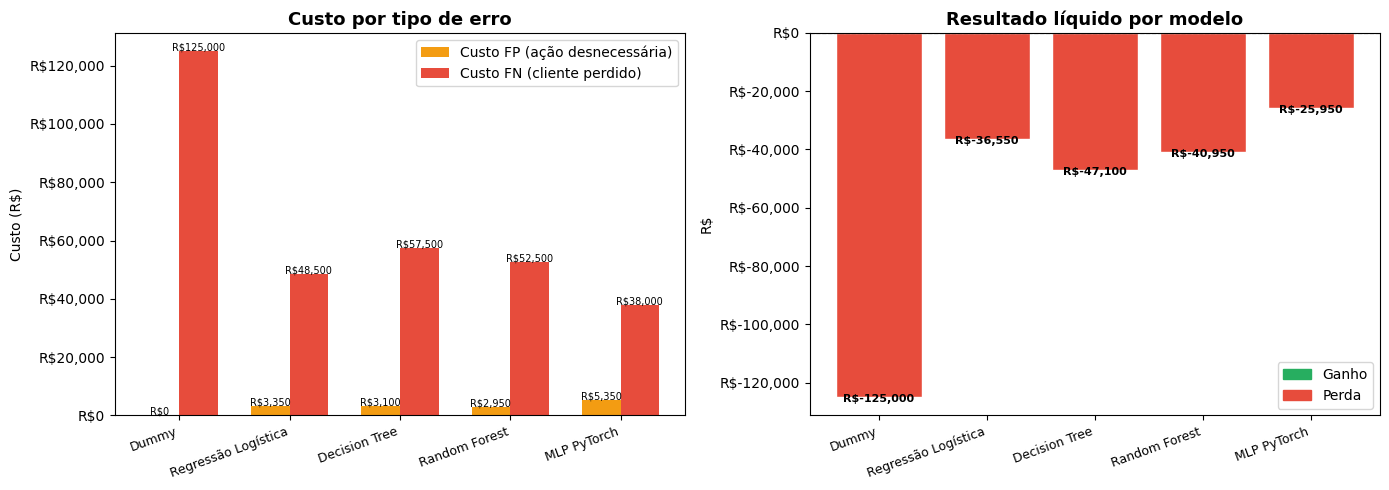


🏆 Melhor modelo financeiramente : MLP PyTorch
   Resultado líquido estimado    : R$ -25,950.00
   FP (ações desnecessárias)     : 107 clientes → R$ 5,350.00
   FN (clientes perdidos)        : 76 clientes → R$ 38,000.00


In [ ]:
#PARÂMETROS DE NEGÓCIO
LTV            = 500   # receita perdida por cliente que cancela
CUSTO_RETENCAO = 50    # custo de abordar um cliente (desconto, ligação...)
TAXA_RETENCAO  = 0.30  # % de clientes que ficam quando abordados

# FUNÇÃO DE CUSTO
def calcular_custo(y_true, y_pred, ltv, custo_retencao, taxa_retencao):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    ganho_vp  = tp * (taxa_retencao * ltv - custo_retencao)  # reteve e ganhou
    custo_fp  = fp * custo_retencao                          # abordou à toa
    custo_fn  = fn * ltv                                     # perdeu o cliente
    resultado = ganho_vp - custo_fp - custo_fn

    return {
        "VP": int(tp), "FP": int(fp), "FN": int(fn), "VN": int(tn),
        "ganho_VP": round(ganho_vp, 2),
        "custo_FP": round(custo_fp, 2),
        "custo_FN": round(custo_fn, 2),
        "resultado": round(resultado, 2),
    }

#MATRIZES De Confusão
def values_cm(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}

models = {
    "Dummy":               values_cm(y_test, y_pred_dummy),
    "Regressão Logística": values_cm(y_test, y_pred_lr),
    "Decision Tree":       values_cm(y_test, y_pred_test_tree),
    "Random Forest":       values_cm(y_test, y_pred_test_forest),
    "MLP PyTorch":         values_cm(y_test, pred_mlp),
}

#CALCULAR RESULTADO FINANCEIRO DE CADA MODELO 
resultados = []
for nome, m in models.items():
    y_true = np.array([0]*m["tn"] + [0]*m["fp"] + [1]*m["fn"] + [1]*m["tp"])
    y_pred = np.array([0]*m["tn"] + [1]*m["fp"] + [0]*m["fn"] + [1]*m["tp"])
    r = calcular_custo(y_true, y_pred, LTV, CUSTO_RETENCAO, TAXA_RETENCAO)
    r["modelo"] = nome
    resultados.append(r)

#TABELA NO CONSOLE
print(f"\n{'Modelo':<25} {'FP':>5} {'FN':>5}  {'Custo FP':>11}  {'Custo FN':>11}  {'Resultado':>12}")
print("-" * 75)
for r in resultados:
    print(f"{r['modelo']:<25} {r['FP']:>5} {r['FN']:>5}  "
          f"R$ {r['custo_FP']:>8,.0f}  R$ {r['custo_FN']:>8,.0f}  R$ {r['resultado']:>9,.0f}")

#GRÁFICOS
nomes     = [r["modelo"] for r in resultados]
custo_fp  = [r["custo_FP"] for r in resultados]
custo_fn  = [r["custo_FN"] for r in resultados]
resultado = [r["resultado"] for r in resultados]
x         = np.arange(len(nomes))
w         = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 — Custo FP vs FN por modelo
ax1 = axes[0]
b1 = ax1.bar(x - w/2, custo_fp, w, label="Custo FP (ação desnecessária)", color="#F39C12")
b2 = ax1.bar(x + w/2, custo_fn, w, label="Custo FN (cliente perdido)",    color="#E74C3C")
ax1.set_title("Custo por tipo de erro", fontsize=13, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(nomes, rotation=20, ha="right", fontsize=9)
ax1.set_ylabel("Custo (R$)")
ax1.legend()
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"R${v:,.0f}"))
for b in list(b1) + list(b2):
    h = b.get_height()
    ax1.text(b.get_x() + b.get_width()/2, h + 200, f"R${h:,.0f}", ha="center", fontsize=7)

# Gráfico 2 — Resultado líquido por modelo
ax2 = axes[1]
cores = ["#27AE60" if v >= 0 else "#E74C3C" for v in resultado]
barras = ax2.bar(nomes, resultado, color=cores, edgecolor="white")
ax2.set_title("Resultado líquido por modelo", fontsize=13, fontweight="bold")
ax2.set_xticks(range(len(nomes)))
ax2.set_xticklabels(nomes, rotation=20, ha="right", fontsize=9)
ax2.set_ylabel("R$")
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"R${v:,.0f}"))
ax2.legend(handles=[mpatches.Patch(color="#27AE60", label="Ganho"),
                    mpatches.Patch(color="#E74C3C", label="Perda")])
for b in barras:
    h = b.get_height()
    ax2.text(b.get_x() + b.get_width()/2, h + (300 if h >= 0 else -1500),
             f"R${h:,.0f}", ha="center", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

#CONCLUSÃO
melhor = max(resultados, key=lambda r: r["resultado"])
print(f"\n Melhor modelo financeiramente : {melhor['modelo']}")
print(f"   Resultado líquido estimado    : R$ {melhor['resultado']:,.2f}")
print(f"   FP (ações desnecessárias)     : {melhor['FP']} clientes → R$ {melhor['custo_FP']:,.2f}")
print(f"   FN (clientes perdidos)        : {melhor['FN']} clientes → R$ {melhor['custo_FN']:,.2f}")